
# 11_lunarlander_dqn_variants_sb3.ipynb — Phase 1 (1B)
**LunarLander → DQN Variants: Baseline, Double, Dueling, PER (project-specific)**

Bu defter, Phase 1 içindeki **1B** adımını uygular:
- **Baseline:** SB3 DQN ile hızlı temel skor
- **Custom PyTorch:** DQN eğitim iskeleti
  - **Double DQN** (aşırı iyimserliği azaltma)
  - **Dueling DQN** (V(s) + A(s,a) ayrımı)
  - **PER** (Prioritized Experience Replay; önem ağırlıklı örnekleme)
- **TensorBoard** logları ve **pygame** render demo


## 1) Kurulum

In [3]:

# Gerekirse etkinleştir:
# %pip install -U "stable-baselines3>=2.3.0" "gymnasium[box2d]>=0.29.1" tensorboard pandas matplotlib tqdm
# Box2D bağımlılığı için "gymnasium[box2d]" önemli (LunarLander).


## 2) Kütüphaneler ve Sürüm Bilgisi

In [4]:

import os, time, uuid, json, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from collections import deque, namedtuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter

import gymnasium as gym
import stable_baselines3 as sb3
from stable_baselines3 import DQN as SB3DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.logger import configure
from stable_baselines3.common.evaluation import evaluate_policy

print("Python         ", f"{os.sys.version.split()[0]}")
print("Gymnasium      ", gym.__version__)
print("SB3            ", sb3.__version__)
print("PyTorch        ", torch.__version__)
print("CUDA available ", torch.cuda.is_available())
print("MPS available  ", torch.backends.mps.is_available())
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device   ", device)


Python          3.9.6
Gymnasium       1.1.1
SB3             2.6.0
PyTorch         2.7.1
CUDA available  False
MPS available   True
Using device    mps


## 3) Deney Ayarları ve Klasör Yapısı

In [ ]:

PHASE = "Phase 1"
STEP   = "1B"
NOTEBOOK = "11_lunarlander_dqn_variants_sb3"
ENV_ID = "LunarLander-v3"

SEED = 42
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)

# Ortak hiperparametreler
TOTAL_STEPS_BASELINE = 600_000     # SB3 DQN baseline
EVAL_FREQ_BASELINE   = 10_000.     # her 10k adımda bir değerlendirme

# Custom DQN varsayılanları
TOTAL_STEPS_CUSTOM   = 600_000.   # Custom DQN için de aynı
BATCH_SIZE           = 64.        # Örnekleme sayısı
GAMMA                = 0.99       # İndirim faktörü
LR                   = 2.5e-4     # Öğrenme hızı   
BUFFER_SIZE          = 200_000    # Replay buffer boyutu   
LEARNING_STARTS      = 10_000     # öğrenmeye başlamadan önce doldurulacak adımlar
TRAIN_FREQ           = 4          # her 4 env adımında 1 güncelleme
TARGET_UPDATE        = 1_000      # her 1000 adımda bir hedef ağ güncellemesi
EPS_START            = 1.0        # başlangıçta tamamen keşif
EPS_END              = 0.05       # sonunda %5 keşif
EPS_FRAC             = 0.4        # toplam adımın %40'ında lineer düşüş
N_HIDDEN             = 256        # gizli katman boyutu       

# Klasörler
RUN_ID = time.strftime('%Y%m%d-%H%M%S') + f"-{uuid.uuid4().hex[:6]}"
ROOT_DIR = os.path.join("runs", PHASE, NOTEBOOK, RUN_ID)
CKPT_DIR = os.path.join(ROOT_DIR, "checkpoints")
TB_DIR   = os.path.join(ROOT_DIR, "tb")
MONITOR_DIR = os.path.join(ROOT_DIR, "monitor")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(TB_DIR, exist_ok=True)
os.makedirs(MONITOR_DIR, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("CKPT_DIR:", CKPT_DIR)
print("TB_DIR  :", TB_DIR)
print("MONITOR :", MONITOR_DIR)


ROOT_DIR: runs/Phase 1/11_lunarlander_dqn_variants_sb3/20250930-141146-2b5534
CKPT_DIR: runs/Phase 1/11_lunarlander_dqn_variants_sb3/20250930-141146-2b5534/checkpoints
TB_DIR  : runs/Phase 1/11_lunarlander_dqn_variants_sb3/20250930-141146-2b5534/tb
MONITOR : runs/Phase 1/11_lunarlander_dqn_variants_sb3/20250930-141146-2b5534/monitor


## 4) Ortam Kurulumu (Monitor + pygame render opsiyonu)

In [ ]:
            
def make_env(monitor_dir=None, render=False):
    if render:
        env = gym.make(ENV_ID, render_mode="human")
    else:
        env = gym.make(ENV_ID)
    if monitor_dir is not None:
        env = Monitor(env, monitor_dir)
    return env

train_env = make_env(monitor_dir=MONITOR_DIR, render=False)
eval_env  = make_env(monitor_dir=None, render=False)

obs, info = train_env.reset(seed=SEED)
print("Obs shape:", np.array(obs).shape, "| Action space:", train_env.action_space)
nS = train_env.observation_space.shape[0]
nA = train_env.action_space.n

# OBS 1 : Yatay konum
# OBS 2 : Dikey konum
# OBS 3 : Yatay hız
# OBS 4 : Dikey hız
# OBS 5 : Açı
# OBS 6 : Açısal hız
# OBS 7 : Sol bacak yere temas ediyor mu? (BOOL)
# OBS 8 : Sağ bacak yere temas ediyor mu? (BOOL)

# ACT 0 : Hiçbir şey yapma
# ACT 1 : Sol motoru ateşle (yukarı doğru itiş)
# ACT 2 : Ana motoru ateşle (yukarı doğru itiş)
# ACT 3 : Sağ motoru ateşle (yukarı doğru itiş)


## 5) Baseline: SB3 DQN (hızlı karşılaştırma için)

In [ ]:

policy_kwargs = dict(net_arch=[N_HIDDEN, N_HIDDEN]) # İki gizli katmanlı MLP
sb3_model = SB3DQN(
    "MlpPolicy", train_env,         
    learning_rate=LR,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    gamma=GAMMA,
    train_freq=TRAIN_FREQ,
    target_update_interval=TARGET_UPDATE,
    exploration_fraction=EPS_FRAC,
    exploration_initial_eps=EPS_START,
    exploration_final_eps=EPS_END,
    policy_kwargs=policy_kwargs,
    device="auto",
    verbose=-1,
    seed=SEED
)
sb3_logger = configure(ROOT_DIR, ["stdout", "csv", "tensorboard"])
sb3_model.set_logger(sb3_logger)

print("[SB3] Training baseline DQN...")
sb3_model.learn(total_timesteps=TOTAL_STEPS_BASELINE, progress_bar=True)
sb3_baseline_path = os.path.join(CKPT_DIR, "sb3_dqn_baseline.zip")
sb3_model.save(sb3_baseline_path)
print("[SB3] Saved:", sb3_baseline_path)

print("[SB3] Evaluating...")
mean_r, std_r = evaluate_policy(sb3_model, eval_env, n_eval_episodes=10, deterministic=True)
print(f"[SB3][EVAL] MeanReturn={mean_r:.1f} ± {std_r:.1f}")


Logging to runs/Phase 1/11_lunarlander_dqn_variants_sb3/20250930-141146-2b5534


Output()

[SB3] Training baseline DQN...
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 95.5     |
|    ep_rew_mean      | -180     |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 6737     |
|    time_elapsed     | 0        |
|    total_timesteps  | 382      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 93.2     |
|    ep_rew_mean      | -209     |
|    exploration_rate | 0.996    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 7098     |
|    time_elapsed     | 0        |
|    total_timesteps  | 746      |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 93.9     |
|    ep_rew_mean      | -222     |
|    exploration_rate | 0.993    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 7929     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1127     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 94.9     |
|    ep_rew_mean      | -201     |
|    exploration_rate | 0.991    |
| time/               |          |
|    episodes         | 16       |
|    fps              | 8966     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1519     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 91.8     |
|    ep_rew_mean      | -181     |
|    exploration_rate | 0.989    |
| time/               |          |
|    episodes       

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 86.3     |
|    ep_rew_mean      | -167     |
|    exploration_rate | 0.984    |
| time/               |          |
|    episodes         | 32       |
|    fps              | 10504    |
|    time_elapsed     | 0        |
|    total_timesteps  | 2763     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 88.1     |
|    ep_rew_mean      | -167     |
|    exploration_rate | 0.981    |
| time/               |          |
|    episodes         | 36       |
|    fps              | 10886    |
|    time_elapsed     | 0        |
|    total_timesteps  | 3172     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 89.1     |
|    ep_rew_mean      | -170     |
|    exploration_rate | 0.979    |
| time/               |          |
|    episodes       

...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 384      |
|    ep_rew_mean      | 255      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1336     |
|    fps              | 1975     |
|    time_elapsed     | 199      |
|    total_timesteps  | 394393   |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 1.38     |
|    n_updates        | 96098    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 391      |
|    ep_rew_mean      | 253      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1340     |
|    fps              | 1974     |
|    time_elapsed     | 200      |
|    total_timesteps  | 396735   |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.267    |
|    n_updates        | 96683    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 392      |
|    ep_rew_mean      | 254      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1344     |
|    fps              | 1973     |
|    time_elapsed     | 201      |
|    total_timesteps  | 397942   |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.661    |
|    n_updates        | 96985    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 389      |
|    ep_rew_mean      | 254      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1348     |
|    fps              | 1973     |
|    time_elapsed     | 202      |
|    total_timesteps  | 399168   |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.143    |
|    n_updates        | 97291    |
----------------------------------


[SB3] Saved: runs/Phase 1/11_lunarlander_dqn_variants_sb3/20250930-141146-2b5534/checkpoints/sb3_dqn_baseline.zip
[SB3] Evaluating...
[SB3][EVAL] MeanReturn=68.7 ± 110.8



## 6) Teori (detaylı notlar — defterlik)

### 6.1 DQN Temeli
- **Amaç:** Q-ağını öğrenmek: \( Q_\theta(s,a) \).  
- **Hedef (target):**  
  \( y = r + \gamma \max_{a'} Q_{\theta^-}(s', a') \cdot (1-\mathrm{done}) \)  
  \(\theta^-\) sabit **hedef ağ** parametreleri (periyodik kopyalanır).  
- **Kayıp:** \( \mathcal{L} = \big(y - Q_\theta(s,a)\big)^2 \) (Huber da kullanılabilir).  
- **Replay buffer:** Korelasyonu kırar, veri verimliliğini artırır.  
- **\(\epsilon\)-greedy:** Keşif/sömürü dengesi.

### 6.2 Double DQN — aşırı iyimserliği azaltma
- DQN’de \(\max\) işlemi aynı ağdan hem **eylem seçimi** hem de **değer tahmini** için kullanılır → **overestimation**.
- **Double DQN hedefi:**  
  \( a^* = \arg\max_{a'} Q_\theta(s', a') \) (online ağ ile seçim)  
  \( y = r + \gamma Q_{\theta^-}(s', a^*) \cdot (1-\mathrm{done}) \) (target ağ ile değerleme)  
- Etki: Daha **ölçülü** Q, daha istikrarlı eğitim.

### 6.3 Dueling DQN — durum değerini daha iyi ayırmak
- Q’yu iki kola ayır: **Değer kolu** \(V(s)\) ve **Avantaj kolu** \(A(s,a)\).  
- Birleştirme:  
  \( Q(s,a) = V(s) + \big(A(s,a) - \frac{1}{|\mathcal{A}|}\sum_{a'}A(s,a')\big) \)  
- Etki: Görünürde eylem farkı az olan durumlarda bile **durum değeri** iyi tahmin edilir.

### 6.4 PER — Prioritized Experience Replay
- Her geçişe **öncelik** (priority) ver: hata büyükse örnek daha “bilgi taşıyıcıdır”.  
- Örnekleme olasılığı \( P(i) \propto p_i^\alpha \).  
- **IS (importance sampling) ağırlıkları:** \( w_i = (N \cdot P(i))^{-\beta} \) (bias telafisi).  
- Alfa (\(\alpha\)): ne kadar öncelik. Beta (\(\beta\)): IS düzeltme gücü (zamanla 1’e anneal).  
- Etki: Öğrenmeyi hızlandırabilir, nadir “kritik” geçişleri daha sık görür.


## 7) Custom Bileşenler: Replay & PER SumTree

In [ ]:
# === 7) Custom Bileşenler: Replay & PER SumTree  ===
from collections import namedtuple, deque
Transition = namedtuple("Transition", ["s","a","r","ns","d"])

class SumTree:
    """
    Segment tree tabanlı öncelikli örnekleme ağacı.
    'update' DATA İNDEKSİ (0..capacity-1) alır; internal leaf = data_idx + capacity.
    """
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity, dtype=np.float32)  # 1-indexed internal
        self.data = [None] * capacity
        self.write = 0
        self.n_entries = 0

    def _propagate(self, leaf_idx, change):
        idx = leaf_idx // 2
        while idx >= 1:
            self.tree[idx] += change
            idx //= 2

    def update(self, data_idx, p):
        leaf = data_idx + self.capacity
        change = p - self.tree[leaf]
        self.tree[leaf] = p
        self._propagate(leaf, change)

    def add(self, p, data):
        data_idx = self.write
        self.data[data_idx] = data
        self.update(data_idx, p)
        self.write = (self.write + 1) % self.capacity
        self.n_entries = min(self.n_entries + 1, self.capacity)

    def total(self):
        return float(self.tree[1])

    def get(self, s):
        # s ∈ [0, total]
        idx = 1
        while idx < self.capacity:
            left = 2 * idx
            right = left + 1
            if self.tree[left] >= s:
                idx = left
            else:
                s -= self.tree[left]
                idx = right
        data_idx = idx - self.capacity
        return idx, float(self.tree[idx]), self.data[data_idx], data_idx  # leaf_idx, p, data, data_idx


class PERReplay:
    """
    Güçlü/robust örnekleme: None yakalanırsa yeniden örnekleme yapılır.
    update_priorities leaf_idx -> data_idx dönüştürüp SumTree.update çağırır.
    """
    def __init__(self, capacity, alpha=0.6, beta_start=0.4, beta_frames=500_000, eps=1e-5):
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.beta_start = beta_start
        self.beta_frames = beta_frames
        self.eps = eps
        self.frame = 1
        self.max_p = 1.0

    def beta_by_frame(self):
        return min(1.0, self.beta_start + (1.0 - self.beta_start) * self.frame / self.beta_frames)

    def push(self, trans: Transition):
        # Başlangıçta tüm yeni girişlere en yüksek öncelik ver (keşfi hızlandırır)
        p = self.max_p ** self.alpha
        self.tree.add(p, trans)

    def sample(self, batch_size):
        assert self.tree.n_entries > 0 and self.tree.total() > 0.0, "PER total=0 — buffer henüz dolmamış."
        batch, leaf_idxs, priorities = [], [], []
        segment = self.tree.total() / batch_size

        for i in range(batch_size):
            # Robust yeniden örnekleme döngüsü
            data = None; leaf_idx = None; p = 0.0
            tries = 0
            while data is None:
                tries += 1
                # segment içinde uniform örnekle
                s = random.uniform(segment * i, segment * (i + 1))
                leaf_idx, p, data, data_idx = self.tree.get(s)
                if data is None:
                    # Segmentte boş yaprak denk geldiyse, tüm aralıktan tekrar dene
                    s = random.uniform(0.0, max(self.tree.total(), 1e-8))
                    leaf_idx, p, data, data_idx = self.tree.get(s)
                if tries > 5 and data is None:
                    # Hâlâ None ise, yazma işaretçisinin gerisindeki rastgele dolu indeksten çek
                    ridx = np.random.randint(0, self.tree.n_entries)
                    data = self.tree.data[ridx]
                    # p'yi sıfır bırakma; küçük de olsa pozitif bir öncelik kullan
                    p = 1e-6
                    leaf_idx = ridx + self.tree.capacity

            batch.append(data); leaf_idxs.append(leaf_idx); priorities.append(max(p, 1e-12))

        total = self.tree.total()
        probs = np.array(priorities) / (total + 1e-12)
        beta = self.beta_by_frame()
        weights = (self.tree.n_entries * probs) ** (-beta)
        weights /= (weights.max() + 1e-12)
        self.frame += 1
        return leaf_idxs, batch, torch.as_tensor(weights, dtype=torch.float32)

    def update_priorities(self, leaf_idxs, td_errors):
        td = np.abs(td_errors.detach().cpu().numpy()) + self.eps
        for leaf_idx, e in zip(leaf_idxs, td):
            data_idx = int(leaf_idx - self.tree.capacity)  # leaf -> data
            if 0 <= data_idx < self.tree.capacity:
                p = float(e) ** self.alpha
                self.tree.update(data_idx, p)
                self.max_p = max(self.max_p, float(e))

    def __len__(self):
        return self.tree.n_entries


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    def push(self, trans: Transition):
        self.buffer.append(trans)
    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)
    def __len__(self):
        return len(self.buffer)


## 8) Custom Ağlar: Standart Q ve Dueling Q

In [9]:

class QNet(nn.Module):
    def __init__(self, nS, nA, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nS, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, nA)
        )
    def forward(self, x):
        return self.net(x)

class DuelingQNet(nn.Module):
    def __init__(self, nS, nA, hidden=256):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(nS, hidden), nn.ReLU()
        )
        self.adv = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, nA)
        )
        self.val = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        f = self.feature(x)
        A = self.adv(f)
        V = self.val(f)
        A = A - A.mean(dim=1, keepdim=True)
        Q = V + A
        return Q


## 9) Custom DQN Eğitici (Double / Dueling / PER seçenekli)

In [ ]:
# ## 9) Custom DQN Eğitici (Double / Dueling / PER seçenekli)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import random

# Not: QNet / DuelingQNet ile PERReplay / ReplayBuffer önceki hücrelerde tanımlı olmalı.

class DQNTrainer:
    def __init__(self, nS, nA, dueling=False, double=True, per=False,
                 gamma=0.99, lr=2.5e-4, batch_size=64,
                 buffer_size=200_000, learning_starts=10_000,
                 train_freq=4, target_update=1000,
                 eps_start=1.0, eps_end=0.05, eps_frac=0.4,
                 hidden=256, tb_dir=".", seed=42, device="cpu"):
        self.nS, self.nA = nS, nA
        self.gamma = gamma
        self.batch_size = batch_size
        self.learning_starts = learning_starts
        self.train_freq = train_freq
        self.target_update = target_update
        self.device = device
        self.double = double
        self.per = per
        self.dueling = dueling

        Net = DuelingQNet if dueling else QNet
        self.q = Net(nS, nA, hidden).to(device)
        self.qt = Net(nS, nA, hidden).to(device)
        self.qt.load_state_dict(self.q.state_dict())
        self.optim = Adam(self.q.parameters(), lr=lr)

        self.eps_start, self.eps_end, self.eps_frac = eps_start, eps_end, eps_frac
        self.total_steps = 0

        if per:
            # PERReplay: SumTree tabanlı, update_priorities FIX uygulanmış olmalı
            self.buffer = PERReplay(buffer_size, alpha=0.6, beta_start=0.4, beta_frames=buffer_size)
        else:
            self.buffer = ReplayBuffer(buffer_size)

        self.writer = SummaryWriter(tb_dir)
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    def epsilon(self, step, max_steps):
        # lineer azalım: toplam adımların eps_frac yüzdesinde
        frac = min(1.0, step / (max_steps * self.eps_frac + 1e-8))
        return self.eps_start + frac * (self.eps_end - self.eps_start)

    @torch.no_grad()
    def act(self, s, max_steps):
        eps = self.epsilon(self.total_steps, max_steps)
        if random.random() < eps:
            a = random.randrange(self.nA)
        else:
            s_t = torch.as_tensor(s, dtype=torch.float32, device=self.device).unsqueeze(0)
            q = self.q(s_t)
            a = int(q.argmax(dim=1).item())
        return a, eps

    def push(self, s, a, r, ns, d):
        trans = Transition(s, a, r, ns, d)
        self.buffer.push(trans)

    def update(self):
        # 1) Öğrenmeye erken başlama ve train_freq kontrolü
        if len(self.buffer) < self.learning_starts or self.total_steps % self.train_freq != 0:
            return None

        # 2) Örnekleme
        if self.per:
            idxs, batch, weights = self.buffer.sample(self.batch_size)
        else:
            batch = self.buffer.sample(self.batch_size)
            weights = torch.ones(self.batch_size, dtype=torch.float32)

        # 3) Güvenlik: batch içinde None veya eksik örnek varsa atla
        batch = [t for t in batch if (t is not None and getattr(t, "s", None) is not None)]
        if len(batch) < self.batch_size:
            return None  # Bu adımı es geç; bir sonraki adımda tekrar dene

        # 4) Tensörlere çevir
        s  = torch.as_tensor(np.stack([t.s  for t in batch]), dtype=torch.float32, device=self.device)
        a  = torch.as_tensor([t.a  for t in batch], dtype=torch.int64,   device=self.device).unsqueeze(1)
        r  = torch.as_tensor([t.r  for t in batch], dtype=torch.float32, device=self.device).unsqueeze(1)
        ns = torch.as_tensor(np.stack([t.ns for t in batch]), dtype=torch.float32, device=self.device)
        d  = torch.as_tensor([t.d  for t in batch], dtype=torch.float32, device=self.device).unsqueeze(1)
        w  = weights.to(self.device).unsqueeze(1)

        # 5) Hedef (Double DQN destekli)
        with torch.no_grad():
            q_next_online = self.q(ns)
            if self.double:
                a_star = q_next_online.argmax(dim=1, keepdim=True)      # seçim online ağ
                q_next_target = self.qt(ns)
                q_next = q_next_target.gather(1, a_star)                # değer target ağ
            else:
                q_next_target = self.qt(ns)
                q_next, _ = q_next_target.max(dim=1, keepdim=True)

            y = r + (1.0 - d) * self.gamma * q_next

        # 6) Kayıp / geri yayılım
        q_sa = self.q(s).gather(1, a)
        td_err = y - q_sa
        loss = (w * F.smooth_l1_loss(q_sa, y, reduction="none")).mean()

        self.optim.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q.parameters(), 10.0)
        self.optim.step()

        # 7) PER ise öncelikleri güncelle (FIX: idxs + td_err.squeeze(1))
        if self.per:
            self.buffer.update_priorities(idxs, td_err.squeeze(1))

        # 8) Target ağ senkronizasyonu
        if self.total_steps % self.target_update == 0:
            self.qt.load_state_dict(self.q.state_dict())

        # 9) Loglamak üzere çıktılar
        return loss.item(), td_err.abs().mean().item()

    def close(self):
        self.writer.flush()
        self.writer.close()


## 10) Custom Eğitim Döngüsü (Double/Dueling/PER kombinasyonları)

In [11]:

from tqdm import trange

def train_custom(double=True, dueling=False, per=False, total_steps=TOTAL_STEPS_CUSTOM, tag="custom"):
    env = make_env(monitor_dir=None, render=False)
    eval_env = make_env(monitor_dir=None, render=False)
    tb_run = os.path.join(TB_DIR, f"{tag}_{'dbl' if double else 'std'}_{'duel' if dueling else 'plain'}_{'per' if per else 'rb'}")
    agent = DQNTrainer(
        nS=nS, nA=nA, dueling=dueling, double=double, per=per,
        gamma=GAMMA, lr=LR, batch_size=BATCH_SIZE,
        buffer_size=BUFFER_SIZE, learning_starts=LEARNING_STARTS,
        train_freq=TRAIN_FREQ, target_update=TARGET_UPDATE,
        eps_start=EPS_START, eps_end=EPS_END, eps_frac=EPS_FRAC,
        hidden=N_HIDDEN, tb_dir=tb_run, seed=SEED, device=("cuda" if torch.cuda.is_available() else "cpu")
    )

    s, info = env.reset(seed=SEED)
    ep_ret, ep_len = 0.0, 0
    best_eval = -1e9

    for step in trange(1, total_steps + 1):
        a, eps = agent.act(s, total_steps)
        ns, r, done, truncated, info = env.step(a)
        d = float(done or truncated)
        agent.push(s, a, r, ns, d)
        s = ns; ep_ret += r; ep_len += 1
        agent.total_steps = step

        out = agent.update()
        if out is not None:
            loss, td = out
            agent.writer.add_scalar("train/loss", loss, step)
            agent.writer.add_scalar("train/td_abs_mean", td, step)
            agent.writer.add_scalar("train/eps", eps, step)

        if done or truncated:
            agent.writer.add_scalar("rollout/ep_rew", ep_ret, step)
            agent.writer.add_scalar("rollout/ep_len", ep_len, step)
            s, info = env.reset()
            ep_ret, ep_len = 0.0, 0

        if step % 10_000 == 0:
            R = 0.0
            for _ in range(5):
                o, _ = eval_env.reset(seed=SEED+_)
                dr = tr = False
                epR = 0.0
                while not (dr or tr):
                    with torch.no_grad():
                        st = torch.as_tensor(o, dtype=torch.float32).unsqueeze(0)
                        q = agent.q(st.to(agent.device))
                        act = int(q.argmax(dim=1))
                    o, rr, dr, tr, _ = eval_env.step(act)
                    epR += rr
                R += epR
            R /= 5.0
            agent.writer.add_scalar("eval/mean_return", R, step)
            if R > best_eval:
                best_eval = R
                torch.save(agent.q.state_dict(), os.path.join(CKPT_DIR, f"{tag}_best_{step}.pth"))

    torch.save(agent.q.state_dict(), os.path.join(CKPT_DIR, f"{tag}_final.pth"))
    agent.close()
    env.close(); eval_env.close()
    return True

print("Custom eğitim fonksiyonu hazır.")


Custom eğitim fonksiyonu hazır.


## 11) Deney Seti: Double, Dueling, PER

In [12]:

# A) Double DQN (saf)
train_custom(double=True, dueling=False, per=False, total_steps=TOTAL_STEPS_CUSTOM, tag="double")

# B) Double + Dueling
train_custom(double=True, dueling=True, per=False, total_steps=TOTAL_STEPS_CUSTOM, tag="double_dueling")

# C) Double + Dueling + PER
train_custom(double=True, dueling=True, per=True, total_steps=TOTAL_STEPS_CUSTOM, tag="double_dueling_per")


100%|██████████| 600000/600000 [08:47<00:00, 1136.57it/s]


True


## 12) TensorBoard Kullanımı (anlamlarıyla)
Terminalde:
```
tensorboard --logdir runs/
```
Bakılacak etiketler:
- **rollout/ep_rew**: Her epizot ödülü (yukarı iyi).
- **rollout/ep_len**: Epizod uzunluğu (LunarLander’da ödül ile birlikte yorumla).
- **train/loss**: Huber/MSE kaybı (Double ile daha tutarlı iniş).
- **train/td_abs_mean**: Ortalama |TD| (PER ile dalgalanma artabilir).
- **train/eps**: ε; keşif hızını (EPS_FRAC) etkiler.
- **eval/mean_return**: 10k adımda bir değerleme; varyant karşılaştırması için ana gösterge.

Varyant yorumu:
- **Double**: Daha güvenilir Q; overestimation azalır.
- **Dueling**: Belirsiz durumlarda daha iyi durum değeri, erken yükseliş.
- **PER**: Erken hızlanma, fakat dalgalanma/overfit riski ⇒ `beta` annealing önemli.


## 13) pygame Render Demo (isteğe bağlı)

In [16]:

def render_demo_pytorch(ckpt_path, dueling=False, episodes=3):
    Net = DuelingQNet if dueling else QNet
    net = Net(nS, nA, hidden=N_HIDDEN)
    net.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
    net.eval()

    env = make_env(monitor_dir=None, render=True)
    try:
        for ep in range(episodes):
            o, _ = env.reset(seed=SEED+ep)
            dr=tr=False
            ret=0.0
            while not (dr or tr):
                with torch.no_grad():
                    q = net(torch.as_tensor(o, dtype=torch.float32).unsqueeze(0))
                    a = int(q.argmax(dim=1))
                o, r, dr, tr, _ = env.step(a)
                ret += r
            print(f"[RENDER] Episode {ep+1} Return={ret:.1f}")
    finally:
        env.close()

# Örnek kullanım:
render_demo_pytorch(os.path.join(CKPT_DIR, "double_dueling_per_final.pth"), dueling=True, episodes=3)


[RENDER] Episode 1 Return=147.1
[RENDER] Episode 2 Return=271.2
[RENDER] Episode 3 Return=309.8


## 14) Meta Bilgi

In [15]:

meta = {
    "phase": PHASE,
    "step": STEP,
    "notebook": NOTEBOOK,
    "env_id": ENV_ID,
    "seed": SEED,
    "run_id": "{}".format(time.strftime('%Y-%m-%d %H:%M:%S')),
    "root_dir": ROOT_DIR,
    "ckpt_dir": CKPT_DIR,
    "tb_dir": TB_DIR,
    "monitor_dir": MONITOR_DIR,
    "variants": ["double", "double_dueling", "double_dueling_per"]
}
with open(os.path.join(ROOT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))


{
  "phase": "Phase 1",
  "step": "1B",
  "notebook": "11_lunarlander_dqn_variants_sb3",
  "env_id": "LunarLander-v3",
  "seed": 42,
  "run_id": "2025-09-30 14:37:25",
  "root_dir": "runs/Phase 1/11_lunarlander_dqn_variants_sb3/20250930-141146-2b5534",
  "ckpt_dir": "runs/Phase 1/11_lunarlander_dqn_variants_sb3/20250930-141146-2b5534/checkpoints",
  "tb_dir": "runs/Phase 1/11_lunarlander_dqn_variants_sb3/20250930-141146-2b5534/tb",
  "monitor_dir": "runs/Phase 1/11_lunarlander_dqn_variants_sb3/20250930-141146-2b5534/monitor",
  "variants": [
    "double",
    "double_dueling",
    "double_dueling_per"
  ]
}


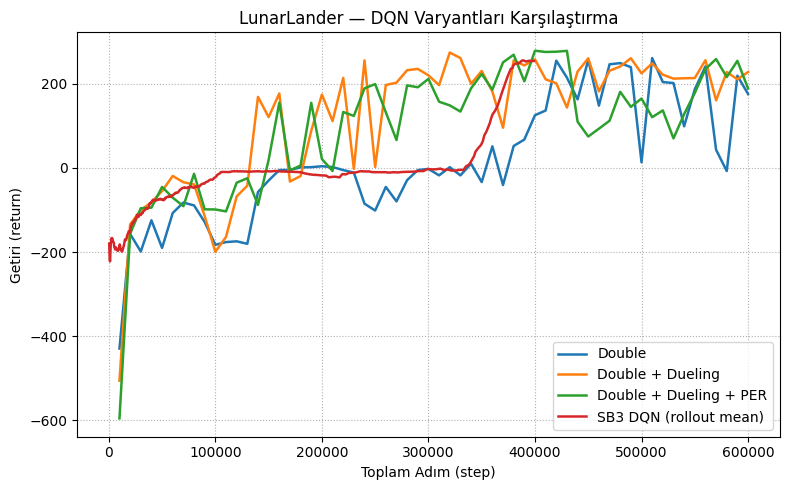

,yöntem,son_step,son_return,en_iyi_return
0,Double + Dueling + PER,600000,188.813538,278.410736
1,Double + Dueling,600000,227.769821,274.118652
2,Double,600000,175.612778,260.975769
3,SB3 DQN (rollout mean),399168,254.124091,255.289706


: 

In [ ]:
# ==== Son Hücre: 4 yöntemi tek grafikte karşılaştırma ====
import os, glob, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorBoard event okuyucu
try:
    from tensorboard.backend.event_processing import event_accumulator as ea
except Exception as e:
    raise RuntimeError("TensorBoard yüklü olmalı: %pip install tensorboard") from e

def load_tb_scalar_series(run_dir: str, tag: str):
    """
    Verilen TB run klasöründen bir scalar tag'ini okur.
    Çıktı: DataFrame(columns=['step','value'])
    """
    files = []
    # event* dosyalarını topla (alt dizinler dahil)
    for root, dirs, fnames in os.walk(run_dir):
        for f in fnames:
            if f.startswith("events.out.tfevents"):
                files.append(os.path.join(root, f))
    if not files:
        return pd.DataFrame(columns=["step","value"])

    dfs = []
    for f in files:
        try:
            acc = ea.EventAccumulator(f, size_guidance={"scalars": 10**7})
            acc.Reload()
            if tag in acc.Tags().get("scalars", []):
                scal = acc.Scalars(tag)
                if scal:
                    steps = [s.step for s in scal]
                    vals  = [s.value for s in scal]
                    dfs.append(pd.DataFrame({"step": steps, "value": vals}))
        except Exception as ex:
            warnings.warn(f"TB dosyası okunamadı: {f} ({ex})")
    if not dfs:
        return pd.DataFrame(columns=["step","value"])
    out = pd.concat(dfs, ignore_index=True).sort_values("step")
    # yinelenen step varsa ortalama al
    out = out.groupby("step", as_index=False)["value"].mean()
    return out

# ---- Yol/etiket eşleşmeleri ----
variant_to_subdir = {
    "Double":               "double_dbl_plain_rb",
    "Double + Dueling":     "double_dueling_dbl_duel_rb",
    "Double + Dueling + PER":"double_dueling_per_dbl_duel_per",
}
tb_tag_custom = "eval/mean_return"      # custom SummaryWriter ile logladığımız tag
sb3_csv_path  = os.path.join(ROOT_DIR, "progress.csv")  # SB3 baseline CSV

# ---- Verileri oku ----
series = {}

# 1) Custom varyantlar (eval/mean_return)
for label, subdir in variant_to_subdir.items():
    run_dir = os.path.join(TB_DIR, subdir)
    df = load_tb_scalar_series(run_dir, tb_tag_custom)
    if len(df):
        series[label] = df.rename(columns={"value":"return"})
    else:
        warnings.warn(f"{label} için '{tb_tag_custom}' bulunamadı: {run_dir}")

# 2) SB3 baseline (progress.csv -> rollout/ep_rew_mean vs time/total_timesteps)
sb3_df = None
if os.path.exists(sb3_csv_path):
    try:
        tmp = pd.read_csv(sb3_csv_path)
        tcol = next((c for c in ["time/total_timesteps","timesteps","total_timesteps"] if c in tmp.columns), None)
        rcol = next((c for c in ["rollout/ep_rew_mean","ep_rew_mean"] if c in tmp.columns), None)
        if tcol and rcol:
            sb3_df = tmp[[tcol, rcol]].dropna().rename(columns={tcol:"step", rcol:"return"})
            # Daha net görmek için (opsiyonel) küçük bir kaydırmalı ortalama uygulayabiliriz
            # ama ham değerleri göstermek daha şeffaf:
            series["SB3 DQN (rollout mean)"] = sb3_df
        else:
            warnings.warn("progress.csv bulundu ama gerekli kolonlar yok.")
    except Exception as e:
        warnings.warn(f"SB3 progress.csv okunamadı: {e}")
else:
    warnings.warn("SB3 progress.csv bulunamadı; SB3 çizgisi eklenmeyecek.")

# ---- Çizim ----
plt.figure(figsize=(8,5))
for label, df in series.items():
    if not len(df): 
        continue
    # X ekseni: step, Y: return
    plt.plot(df["step"].values, df["return"].values, label=label, linewidth=1.8)

plt.title("LunarLander — DQN Varyantları Karşılaştırma")
plt.xlabel("Toplam Adım (step)")
plt.ylabel("Getiri (return)")
plt.grid(True, linestyle=":", linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Kısa tablo özeti (son değere göre)
summary_rows = []
for label, df in series.items():
    if len(df):
        summary_rows.append({
            "yöntem": label,
            "son_step": int(df["step"].iloc[-1]),
            "son_return": float(df["return"].iloc[-1]),
            "en_iyi_return": float(df["return"].max())
        })
if summary_rows:
    display(pd.DataFrame(summary_rows).sort_values("en_iyi_return", ascending=False).reset_index(drop=True))
else:
    print("Özet oluşturulamadı: hiç seri yok.")
